# Interrupted Time Series (ITS) with scikit-learn models

This notebook shows an example of using interrupted time series, where we do not have untreated control units of a similar nature to the treated unit and we just have a single time series of observations and the predictor variables are simply time and month.

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression

import causalpy as cp

In [2]:
%config InlineBackend.figure_format = 'retina'

## Load data

In [3]:
df = (
    cp.load_data("its")
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .set_index("date")
)

treatment_time = pd.to_datetime("2017-01-01")
df.head(5)

,year,month,t,y,causal effect,intercept
date,,,,,,
2010-01-31,2010,1,0,21.554716,0.0,1.0
2010-02-28,2010,2,1,28.851317,0.0,1.0
2010-03-31,2010,3,2,23.258060,0.0,1.0
2010-04-30,2010,4,3,31.936498,0.0,1.0
2010-05-31,2010,5,4,41.090762,0.0,1.0


## Run the analysis

In [4]:
result = cp.InterruptedTimeSeries(
    df,
    treatment_time,
    formula="y ~ 1 + t + C(month)",
    model=LinearRegression(),
)

/Users/benjamv/git/CausalPy/causalpy/experiments/base.py:235: UserWarning: LinearRegression had fit_intercept=True, but CausalPy requires fit_intercept=False because the intercept is already included in the design matrix by patsy. A cloned copy of the model with fit_intercept=False will be used; the original instance is unchanged.


## Examine the results

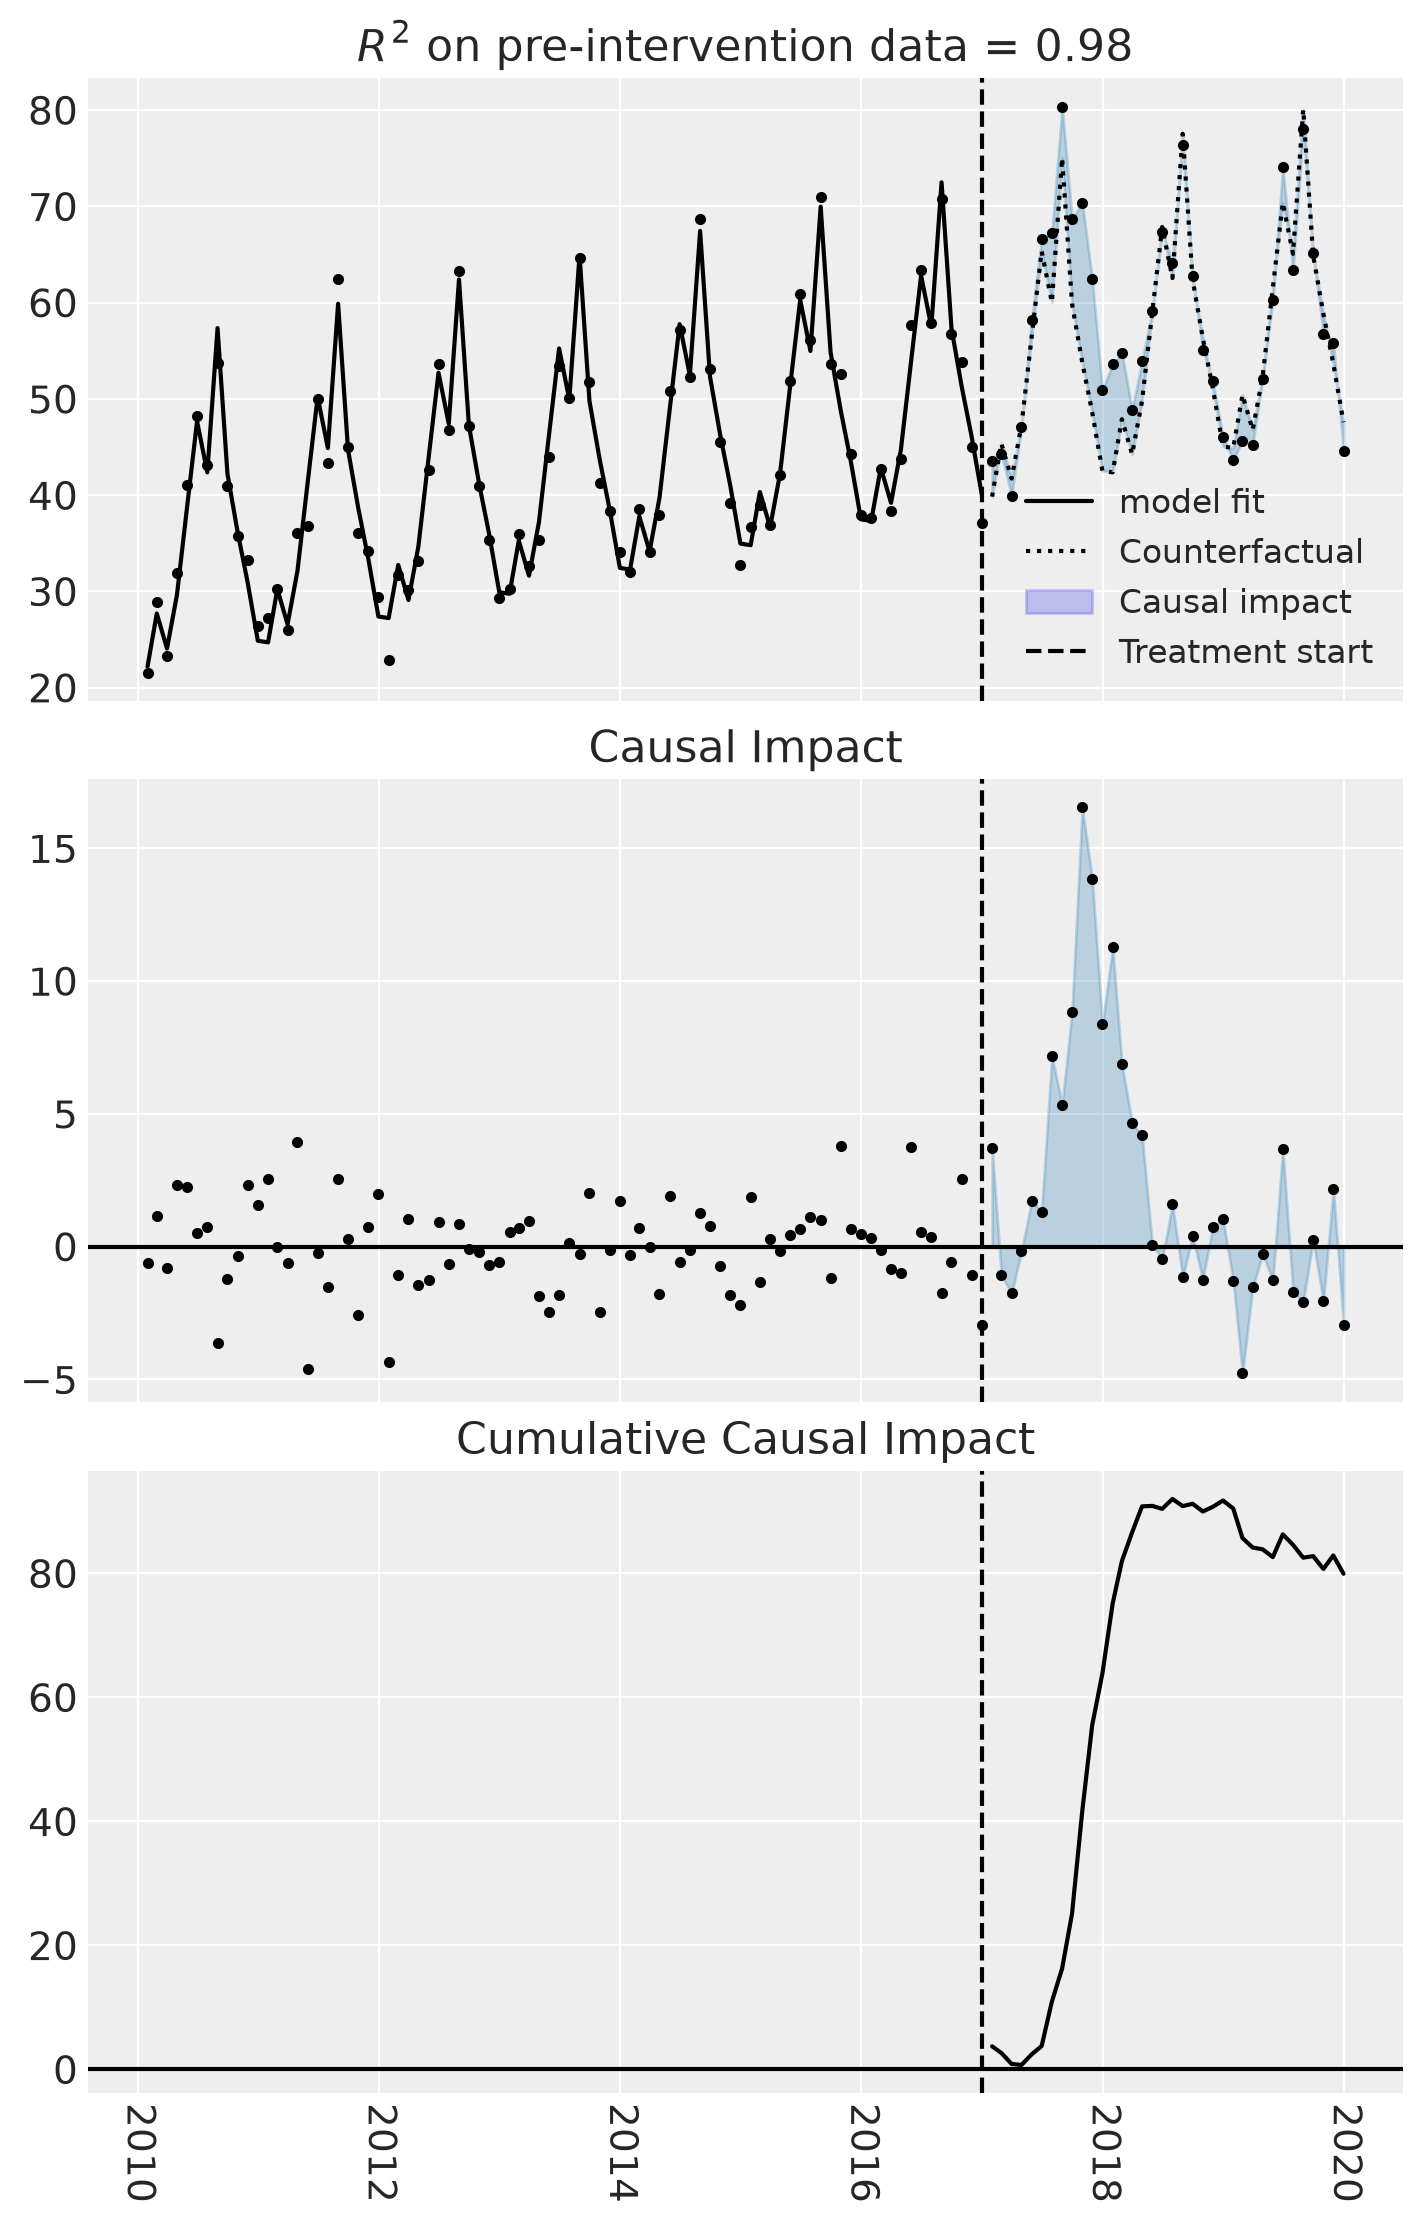

In [5]:
fig, ax = result.plot()

In [6]:
result.summary(round_to=3)

==================================Pre-Post Fit==================================
Formula: y ~ 1 + t + C(month)
Model coefficients:
  Intercept     	      22.2
  C(month)[T.2] 	      5.31
  C(month)[T.3] 	      1.46
  C(month)[T.4] 	       6.8
  C(month)[T.5] 	      15.8
  C(month)[T.6] 	      24.4
  C(month)[T.7] 	      18.9
  C(month)[T.8] 	      33.7
  C(month)[T.9] 	      18.3
  C(month)[T.10]	      12.1
  C(month)[T.11]	      6.67
  C(month)[T.12]	     0.374
  t             	      0.21


We can get nicely formatted tables from our integration with the [maketables](https://github.com/py-econometrics/maketables) package.

In [7]:
from maketables import ETable

ETable(result, coef_fmt="b:.3f")

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x1698e17f0>

## Effect Summary Reporting

For decision-making, you often need a concise summary of the causal effect. The `effect_summary()` method provides a decision-ready report with key statistics.

:::{note}
**OLS vs PyMC Models**: When using OLS models (scikit-learn), the `effect_summary()` provides **confidence intervals** and **p-values** (frequentist inference), rather than the posterior distributions, HDI intervals, and tail probabilities provided by PyMC models (Bayesian inference). OLS tables include: mean, CI_lower, CI_upper, and p_value, but do not include median, tail probabilities (P(effect>0)), or ROPE probabilities.
:::


In [8]:
# Generate effect summary for the full post-period
stats = result.effect_summary()
stats.table

,mean,ci_lower,ci_upper,p_value,relative_mean,relative_ci_lower,relative_ci_upper
average,2.220331,0.576604,3.864058,0.009551,4.420944,1.129960,7.711929
cumulative,79.931912,20.757728,139.106096,0.009551,159.153997,40.678565,277.629429


In [9]:
# View the prose summary
print(stats.text)

During the Post-period (2017-01-31 00:00:00 to 2019-12-31 00:00:00), the response variable had an average value of approx. 57.73. By contrast, in the absence of an intervention, we would have expected an average response of 55.51. The 95% confidence interval of this counterfactual prediction is [53.87, 57.16]. Subtracting this prediction from the observed response yields an estimate of the causal effect the intervention had on the response variable. This effect is 2.22 with a 95% confidence interval of [0.58, 3.86].

Summing up the individual data points during the Post-period, the response variable had an overall value of 2078.37. By contrast, had the intervention not taken place, we would have expected a sum of 1998.44. The 95% confidence interval of this prediction is [1939.26, 2057.61].

The 95% confidence interval of the effect [0.58, 3.86] does not include zero (p-value 0.010). Relative to the counterfactual, the effect represents a 4.42% change (95% CI [1.13%, 7.71%]).

This ana